In [1]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '../_font/NanumGothic-Bold.ttf'
fm.fontManager.addfont(font_path)

font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

print(f"폰트가 '{font_name}'으로 설정되었습니다.")

폰트가 'NanumGothic'으로 설정되었습니다.


In [2]:
import matplotlib.pyplot as plt

# 현재 matplotlib에 설정된 폰트 정보를 출력합니다.
print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")
print(f"현재 설정된 폰트 경로: {fm.findfont(font_prop)}")

현재 설정된 폰트: ['NanumGothic']
현재 설정된 폰트 경로: ../_font/NanumGothic-Bold.ttf


In [3]:
import pandas as pd
import seaborn as sns

# 분석 데이터를 불러옵니다.
df = pd.read_csv("./data/bus_818_arrival_analysis.csv")

# '연번' (회차)을 문자열로 변환하여 범주형 데이터로 처리합니다.
df['연번'] = df['연번'].astype(str)

# 버스 정류장 순서를 정의합니다.
# 시간표에 나타난 순서를 기준으로 하되, 양방향 정류장을 모두 포함하고 실제 데이터에 있는 정류장만 사용합니다.
stop_order = [
    '진량황제A(진량방향)', '대구대정문 건너', '하양역 건너', 
    '상공회의소건너', '안심역(4번출구)', '하양역', 
    '대구대정문', '진량황제A'
]
# 실제 데이터에 존재하는 정류장만 필터링하여 순서를 유지합니다.
ordered_stops = [stop for stop in stop_order if stop in df['정류장'].unique()]
df['정류장'] = pd.Categorical(df['정류장'], categories=ordered_stops, ordered=True)

# 정류장 순서에 따라 데이터를 정렬합니다.
df = df.sort_values('정류장')

print("데이터 로드 및 전처리 완료.")
df.head()

데이터 로드 및 전처리 완료.


,연번,정류장,예정시간,실제도착시간,지연(분)
138,7,진량황제A(진량방향),2020-01-06 07:00:00,2020-01-06 07:01:47,1.78
25,2,진량황제A(진량방향),2020-01-03 05:35:00,2020-01-03 05:33:55,-1.08
89,5,진량황제A(진량방향),2020-01-03 06:30:00,2020-01-03 06:40:21,10.35
187,11,진량황제A(진량방향),2020-01-02 07:30:00,2020-01-02 07:24:10,-5.83
32,2,진량황제A(진량방향),2020-01-06 05:35:00,2020-01-06 06:18:16,43.27


## 1. 회차별 버스 정류장 도착 편차 분석

`README.md`의 **가설 4-a**에 따라, 각 회차(`연번`)별로 버스 정류장 도착 지연 시간(`지연(분)`)을 선 그래프로 시각화합니다. 이를 통해 각 운행 회차의 특성과 전체적인 운행 패턴을 파악할 수 있습니다.

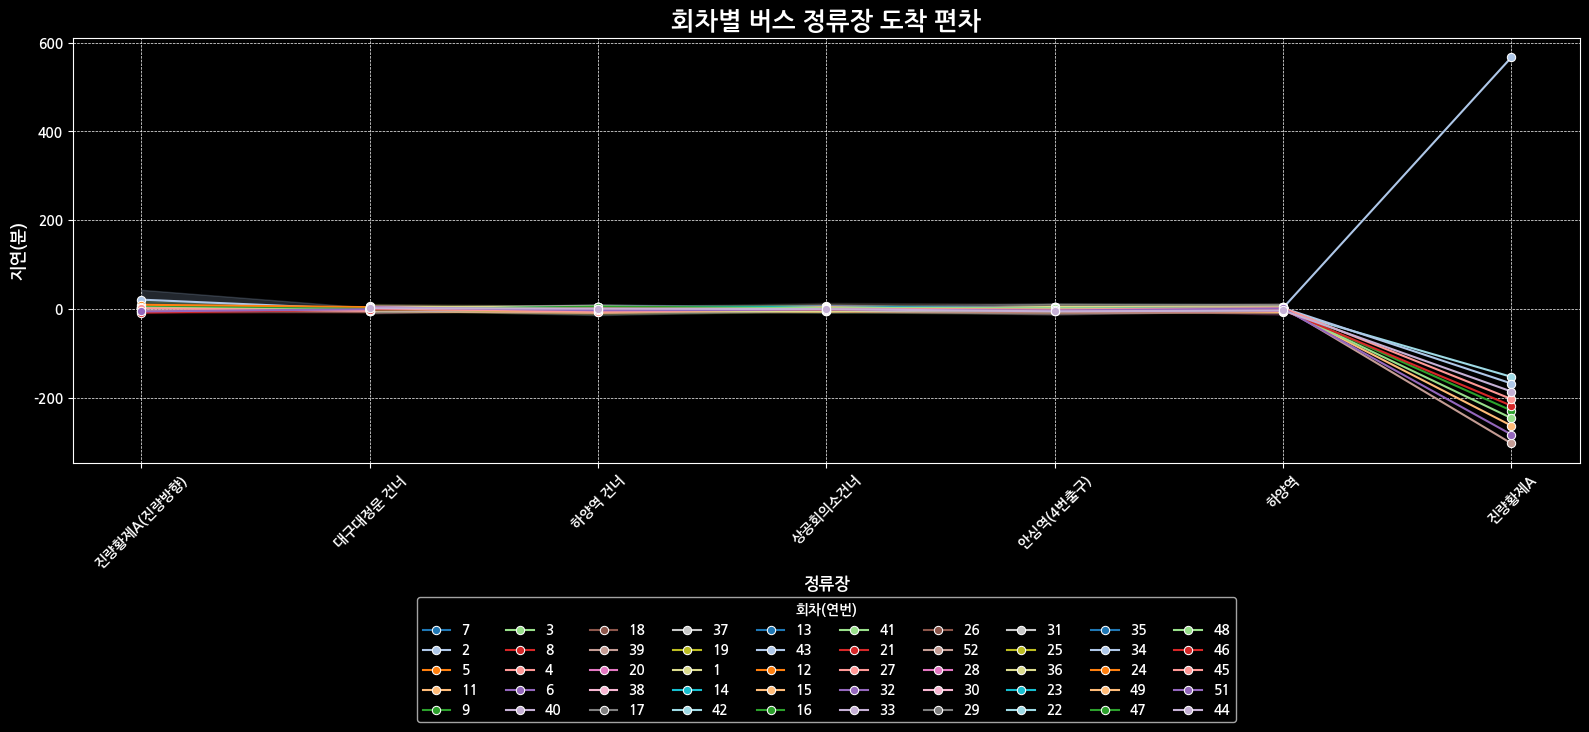

In [4]:
# 그래프 크기를 설정합니다.
plt.figure(figsize=(16, 8))

# seaborn을 사용하여 회차별 도착 편차 선 그래프를 그립니다.
sns.lineplot(
    data=df,
    x='정류장',
    y='지연(분)',
    hue='연번',
    marker='o',
    palette='tab20'  # 다양한 색상 팔레트 사용
)

# 그래프 제목과 축 레이블을 설정합니다.
plt.title('회차별 버스 정류장 도착 편차', fontsize=18)
plt.xlabel('정류장', fontsize=12)
plt.ylabel('지연(분)', fontsize=12)

# x축 레이블이 겹치지 않도록 회전합니다.
plt.xticks(rotation=45)

# 범례를 그래프 하단 바깥쪽에 배치합니다.
plt.legend(title='회차(연번)', bbox_to_anchor=(0.5, -0.3), loc='upper center', ncol=10)

# 그리드를 추가하여 가독성을 높입니다.
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 그래프를 깔끔하게 표시합니다.
plt.tight_layout()
plt.show()

## 2. 정류장별 평균 도착 편차 및 오차 막대 그래프

`README.md`의 **가설 4-b**에 따라, 각 정류장별 평균 지연 시간을 계산하고, 전체 회차에 대한 최소값과 최대값 편차를 오차 막대(Error Bar)로 표현합니다. 이를 통해 어떤 정류장에서 지연 또는 조착이 자주 발생하는지와 그 변동 폭을 직관적으로 확인할 수 있습니다.

/tmp/ipykernel_44128/1432913028.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby('정류장')['지연(분)'].agg(['mean', 'min', 'max']).reset_index()


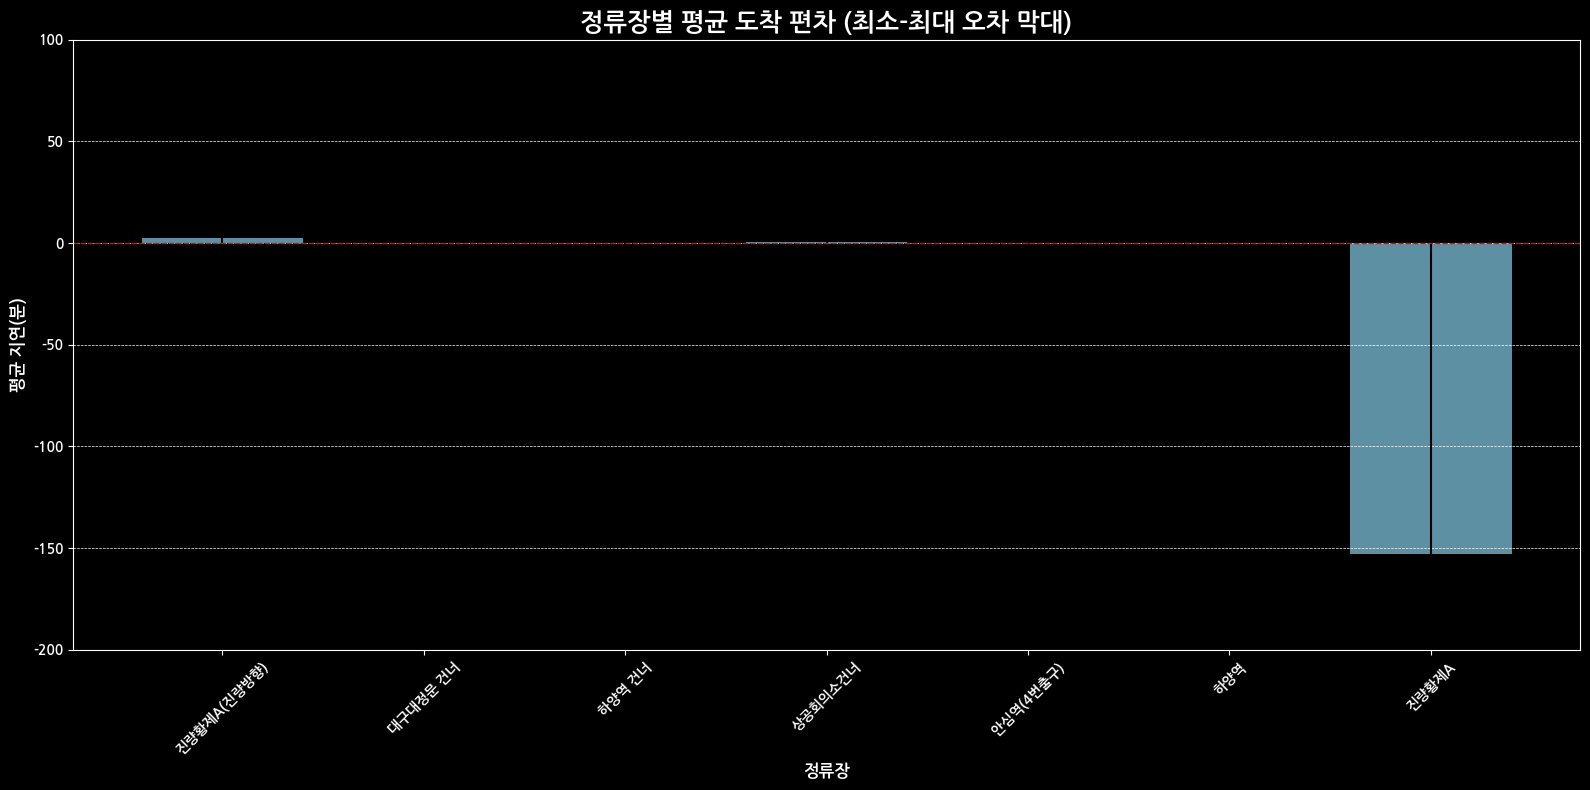

In [5]:
# 정류장별 평균, 최소, 최대 지연 시간을 계산합니다.
agg_df = df.groupby('정류장')['지연(분)'].agg(['mean', 'min', 'max']).reset_index()

# 오차 막대에 사용할 값을 계산합니다. (평균값 기준 편차)
# yerr는 [아래쪽 오차, 위쪽 오차] 형태로 전달해야 합니다.
agg_df['lower_error'] = agg_df['mean'] - agg_df['min']
agg_df['upper_error'] = agg_df['max'] - agg_df['mean']
errors = [agg_df['lower_error'], agg_df['upper_error']]

# 그래프 크기를 설정합니다.
plt.figure(figsize=(16, 8))

# 막대 그래프를 그립니다.
plt.bar(agg_df['정류장'], agg_df['mean'], yerr=errors, capsize=5, color='skyblue', alpha=0.7)

# 0분 기준선을 추가하여 지연/조착을 명확히 구분합니다.
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# 그래프 제목과 축 레이블을 설정합니다.
plt.title('정류장별 평균 도착 편차 (최소-최대 오차 막대)', fontsize=18)
plt.xlabel('정류장', fontsize=12)
plt.ylabel('평균 지연(분)', fontsize=12)

# y축의 범위를 설정하여 가독성을 높입니다.
plt.ylim(-200, 100)

# x축 레이블이 겹치지 않도록 회전합니다.
plt.xticks(rotation=45)

# 그리드를 추가하여 가독성을 높입니다.
plt.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')

# 그래프를 깔끔하게 표시합니다.
plt.tight_layout()
plt.show()